[Config] Device : cuda
[Config] Hash bits : 63
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


[Step 1] Loading image paths...
         Train: 160000  |  Test: 40000
[Step 2] Fine-tuning ResNet-50 on detection task...

[Fine-tune] Adapting ResNet-50 layer4 to detection task...


  Epoch 1/3: 100%|██████████| 5000/5000 [22:38<00:00,  3.68it/s]


  Epoch 1 loss: 0.1738


...

  Epoch 2 loss: 0.0958


  Epoch 3/3: 100%|██████████| 5000/5000 [15:13<00:00,  5.47it/s]


  Epoch 3 loss: 0.0590
[Fine-tune] Complete.

[Step 3] Extracting hybrid features (deep + forensic)...


100%|██████████| 1250/1250 [28:34<00:00,  1.37s/it]


         Deep features : (160000, 2048)
         Forensic feats: (160000, 55)
[Step 4] Fusing and scaling feature spaces (C2)...
[Step 5] Selecting top-64 features via LightGBM ranking...
         Feature space reduced: 2103 → 64
[Step 6] Running GA to optimise dHash feature ordering (C1)...

[GA] Starting optimisation  |  pop=20  gen=25  fitness-subset=4000
[GA] Best fitness (sub-set acc): 0.9980
[GA] Optimal ordering found over 25 generations.

[Step 7] Encoding binary hash codes (3 ablation variants)...
         Binary hash shape: (160000, 63)  (63 bits/image)
[Step 8] Analysing hash code quality...

  Hash quality comparison:
  Variant          Separation    Intra    Inter
  ---------------------------------------------
  Random               23.421   19.363   42.784
  Importance           25.533   18.388   43.921
  GA-Hash              28.929   16.698   45.627

[Step 9] Training ensemble classifiers on binary hash codes...

  → Random-Hash

  Random-Hash
  Accuracy   : 0.9796
  F1

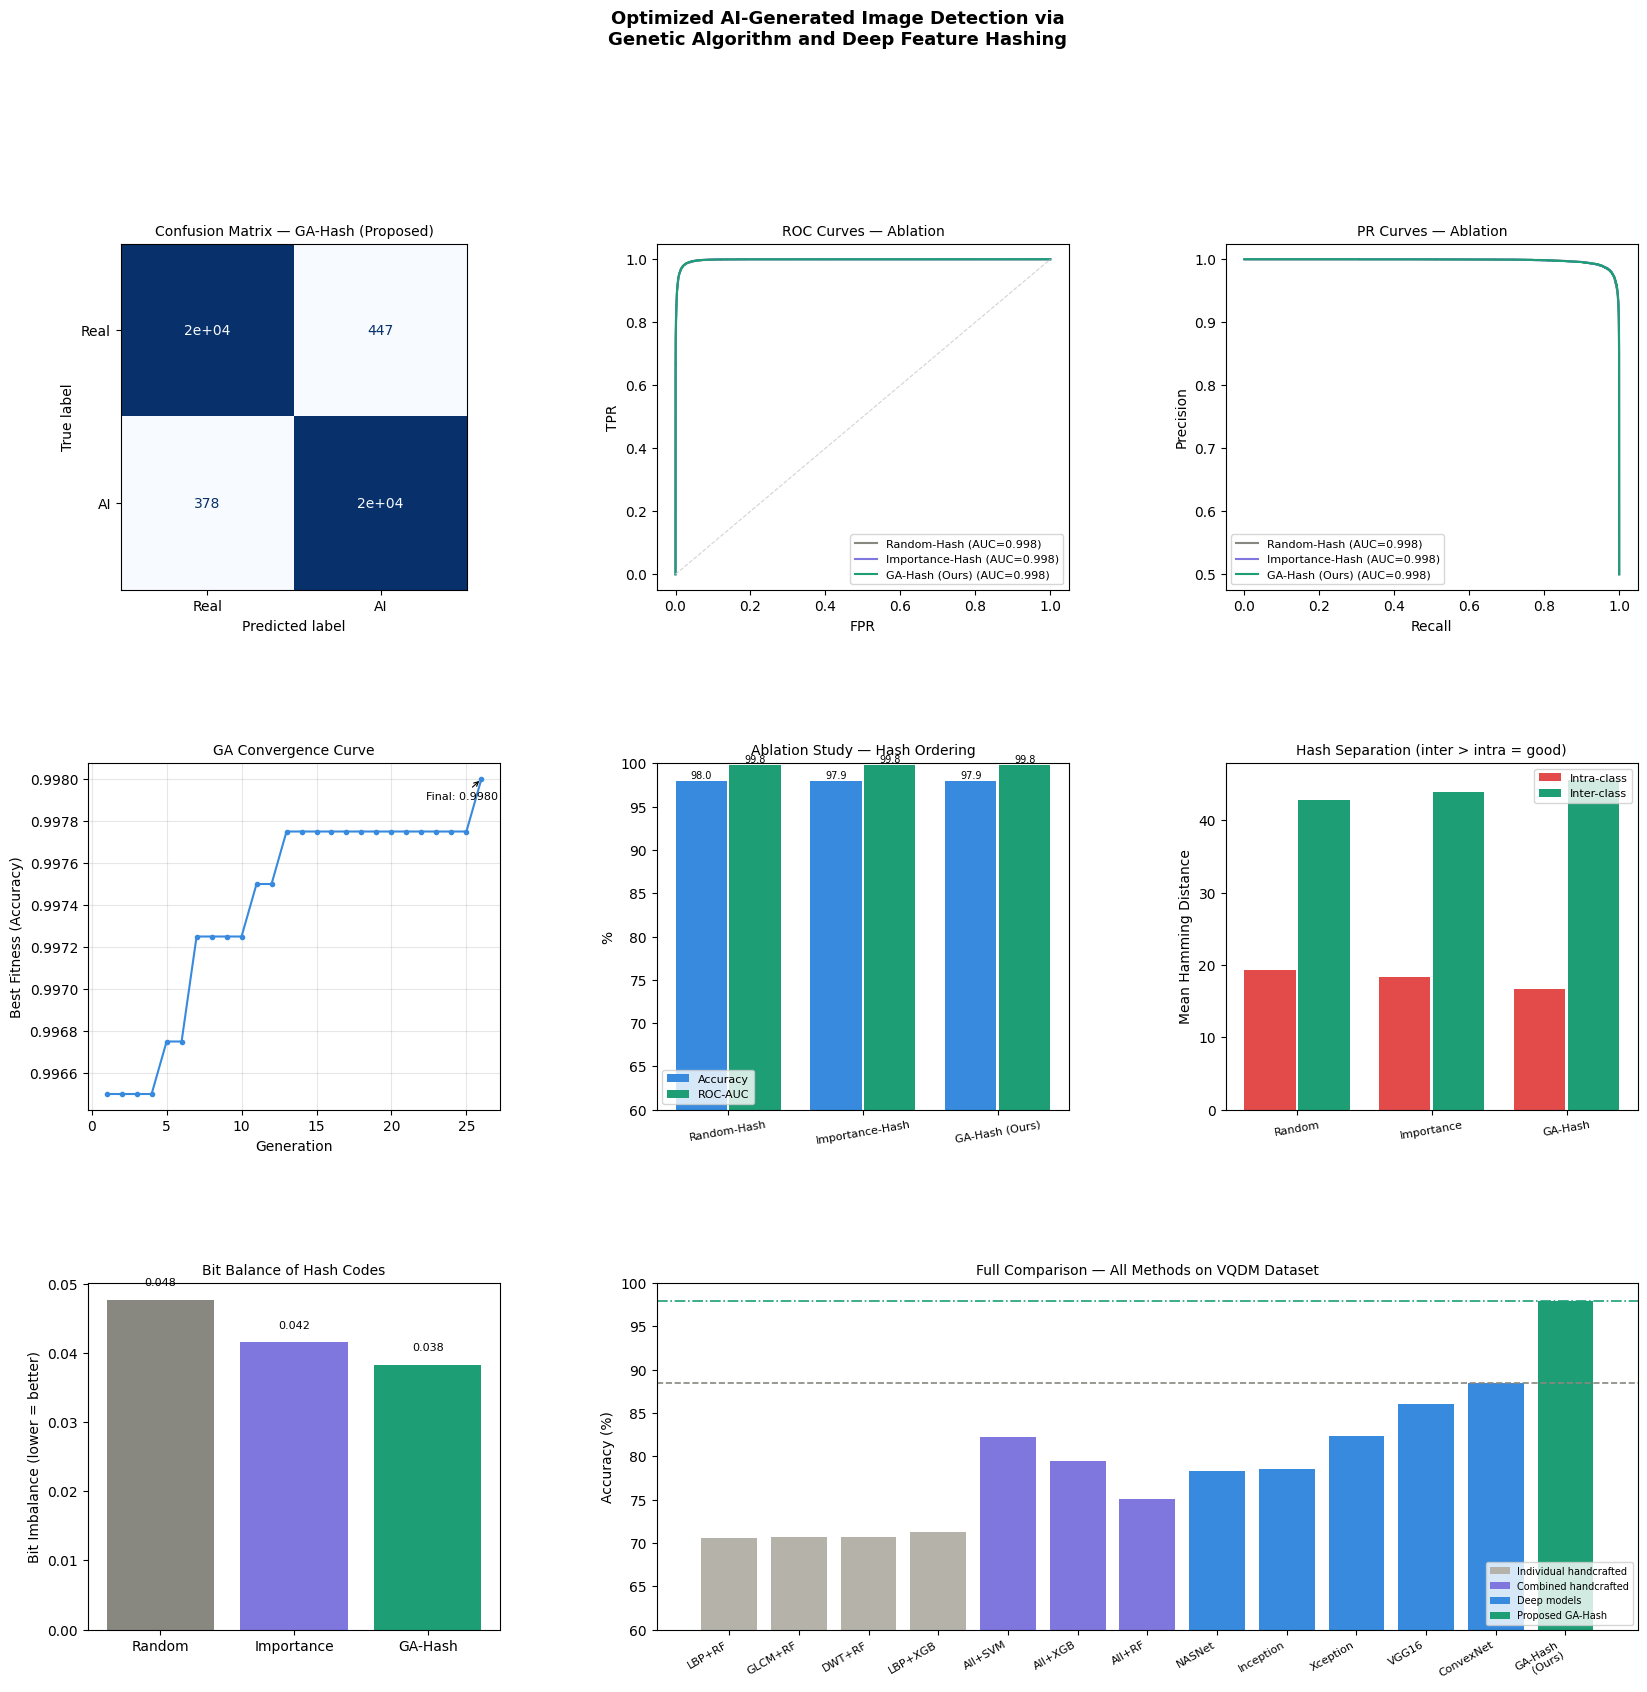

[Plot] Saved to publication_results.png

[Done] Total runtime: 197.56 minutes


In [3]:


# =============================================================================
# SECTION 1 – IMPORTS
# =============================================================================
import os
import cv2
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb

from scipy.fftpack import dct as scipy_dct
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

import pygad

warnings.filterwarnings("ignore")

# =============================================================================
# SECTION 2 – REPRODUCIBILITY
# =============================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =============================================================================
# SECTION 3 – CONFIGURATION
# =============================================================================
DATASET_PATH         = "/kaggle/input/datasets/suryaa0003/vqdm-dataset"
AI_FOLDER            = "ai"
REAL_FOLDER          = "nature"

IMAGE_SIZE           = 224
BATCH_SIZE           = 32           # smaller batch suits fine-tuning on GPU
NUM_IMAGES_PER_CLASS = 100000

FINETUNE_EPOCHS      = 3
FINETUNE_LR          = 1e-4

# --- Hash & GA parameters ---
TOP_K_FEATURES       = 64           # features fed into GA-hash
HASH_BITS            = TOP_K_FEATURES - 1   # dHash produces K-1 bits
GA_SUBSET            = 4000         # sub-sample for fast fitness evaluation
GA_POP               = 20           # GA population
GA_GENS              = 25           # GA generations

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Config] Device : {DEVICE}")
print(f"[Config] Hash bits : {HASH_BITS}")

# =============================================================================
# SECTION 4 – DATA LOADING
# =============================================================================
def load_paths():
    ai_dir   = os.path.join(DATASET_PATH, AI_FOLDER)
    real_dir = os.path.join(DATASET_PATH, REAL_FOLDER)

    ai_files   = random.sample(
        os.listdir(ai_dir),
        min(NUM_IMAGES_PER_CLASS, len(os.listdir(ai_dir)))
    )
    real_files = random.sample(
        os.listdir(real_dir),
        min(NUM_IMAGES_PER_CLASS, len(os.listdir(real_dir)))
    )

    paths  = [os.path.join(ai_dir,   f) for f in ai_files]  + \
             [os.path.join(real_dir, f) for f in real_files]
    labels = [1] * len(ai_files) + [0] * len(real_files)

    return train_test_split(
        paths, labels,
        test_size=0.2, stratify=labels, random_state=SEED
    )

# =============================================================================
# SECTION 5 – DATASET CLASS
# =============================================================================
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

class ForensicDataset(Dataset):
    """Returns (normalised tensor, original path)."""

    def __init__(self, paths, augment=False):
        self.paths = paths
        if augment:
            self.tfm = T.Compose([
                T.Resize((IMAGE_SIZE + 16, IMAGE_SIZE + 16)),
                T.RandomCrop(IMAGE_SIZE),
                T.RandomHorizontalFlip(),
                T.ColorJitter(brightness=0.1, contrast=0.1,
                              saturation=0.1, hue=0.05),
                T.ToTensor(),
                T.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
            ])
        else:
            self.tfm = T.Compose([
                T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                T.ToTensor(),
                T.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        bgr  = cv2.imread(path)
        if bgr is None:
            bgr = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return self.tfm(Image.fromarray(rgb)), path

# =============================================================================
# SECTION 6 – RESNET-50 BACKBONE
# Fine-tune only the last residual block (layer4) for domain adaptation.
# Wang et al. (2020) showed ResNet-50 detects CNN-generated image artifacts;
# we extend this to diffusion-generated images via fine-tuning.
# =============================================================================
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in backbone.parameters():         # freeze everything first
    param.requires_grad = False

for param in backbone.layer4.parameters():  # unfreeze last block
    param.requires_grad = True

backbone.fc = nn.Identity()                  # remove classifier head
backbone    = backbone.to(DEVICE)

def finetune_backbone(train_paths, train_labels):
    """
    Fine-tune ResNet-50 layer4 on the binary detection task.
    This aligns deep feature space with AI-vs-Real discrimination
    rather than ImageNet object categories.
    """
    print("\n[Fine-tune] Adapting ResNet-50 layer4 to detection task...")

    label_map = dict(zip(train_paths, train_labels))
    ds        = ForensicDataset(train_paths, augment=True)
    loader    = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)

    detection_head = nn.Linear(2048, 1).to(DEVICE)
    optimizer      = torch.optim.Adam(
        list(backbone.layer4.parameters()) + list(detection_head.parameters()),
        lr=FINETUNE_LR
    )
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FINETUNE_EPOCHS
    )

    backbone.train()
    detection_head.train()

    for epoch in range(FINETUNE_EPOCHS):
        running_loss = 0.0
        for imgs, paths in tqdm(loader,
                                desc=f"  Epoch {epoch+1}/{FINETUNE_EPOCHS}"):
            imgs        = imgs.to(DEVICE)
            batch_lbl   = torch.tensor(
                [float(label_map[p]) for p in paths],
                dtype=torch.float32
            ).to(DEVICE)

            optimizer.zero_grad()
            logits = detection_head(backbone(imgs)).squeeze(1)
            loss   = criterion(logits, batch_lbl)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        print(f"  Epoch {epoch+1} loss: "
              f"{running_loss / len(loader):.4f}")

    backbone.eval()
    print("[Fine-tune] Complete.\n")

# =============================================================================
# SECTION 7 – HANDCRAFTED FORENSIC FEATURES
# Combines frequency-domain (FFT, DCT), texture (LBP, GLCM),
# colour statistics, and noise residual (Laplacian) into a 55-d vector.
# Each descriptor targets a different class of generative artifact:
#   - FFT/DCT  : spectral fingerprints left by up-sampling layers
#   - LBP      : micro-texture differences (AI images are smoother)
#   - GLCM     : co-occurrence patterns reveal AI uniform regions
#   - Noise    : camera sensor noise absent in synthetic images
#   - Colour   : diffusion models over-saturate specific hue ranges
# =============================================================================
def extract_forensic_features(bgr_img):
    """
    Returns a 55-dimensional float32 forensic feature vector.
    Components:  FFT(5) + DCT(5) + LBP(16) + colour(6)
               + noise(3) + GLCM(12) + saturation(8) = 55 dims
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

    # ── FFT spectral features ────────────────────────────────
    fft_mag  = np.log(np.abs(np.fft.fftshift(np.fft.fft2(gray))) + 1)
    fft_feat = np.array([
        fft_mag.mean(), fft_mag.std(), fft_mag.max(),
        np.percentile(fft_mag, 25), np.percentile(fft_mag, 75)
    ])

    # ── DCT coefficient features ─────────────────────────────
    dct_coef = scipy_dct(
        scipy_dct(gray.astype(np.float32), axis=0, norm='ortho'),
        axis=1, norm='ortho'
    )
    dct_feat = np.array([
        dct_coef.mean(), dct_coef.std(), dct_coef.max(),
        np.percentile(dct_coef, 25), np.percentile(dct_coef, 75)
    ])

    # ── LBP micro-texture histogram ──────────────────────────
    lbp         = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=16,
                               range=(0, 16), density=True)

    # ── Colour channel statistics ────────────────────────────
    colour_feat = np.concatenate([
        bgr_img.mean(axis=(0, 1)),   # per-channel mean (3)
        bgr_img.std(axis=(0, 1))     # per-channel std  (3)
    ])

    # ── Noise residual (Laplacian high-pass) ─────────────────
    noise       = cv2.Laplacian(gray, cv2.CV_64F)
    noise_feat  = np.array([
        noise.mean(),
        noise.std(),
        np.percentile(np.abs(noise), 95)
    ])

    # ── GLCM texture (contrast, homogeneity, energy) ─────────
    g8   = ((gray / gray.max()) * 255).astype(np.uint8) \
           if gray.max() > 0 else gray.astype(np.uint8)
    glcm = graycomatrix(g8, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    glcm_feat = np.concatenate([
        graycoprops(glcm, 'contrast').ravel(),    # 4 values
        graycoprops(glcm, 'homogeneity').ravel(), # 4 values
        graycoprops(glcm, 'energy').ravel()       # 4 values
    ])                                             # = 12 total

    # ── Saturation histogram ─────────────────────────────────
    hsv      = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    sat_hist, _ = np.histogram(hsv[:, :, 1].ravel(), bins=8,
                               range=(0, 256), density=True)

    return np.concatenate([
        fft_feat, dct_feat, lbp_hist,
        colour_feat, noise_feat, glcm_feat, sat_hist
    ]).astype(np.float32)   # total: 5+5+16+6+3+12+8 = 55

# =============================================================================
# SECTION 8 – FEATURE EXTRACTION PIPELINE
# =============================================================================
def extract_all_features(paths):
    """
    Extract (deep features, handcrafted features) for all images.
    Returns: deep (N,2048)  hand (N,55)
    """
    ds     = ForensicDataset(paths, augment=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

    deep_list = []
    hand_list = []

    with torch.no_grad():
        for imgs, batch_paths in tqdm(loader):
            deep_list.extend(backbone(imgs.to(DEVICE)).cpu().numpy())

            for p in batch_paths:
                bgr = cv2.imread(p)
                if bgr is None:
                    bgr = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
                bgr = cv2.resize(bgr, (IMAGE_SIZE, IMAGE_SIZE))
                hand_list.append(extract_forensic_features(bgr))

    return (np.array(deep_list, dtype=np.float32),
            np.array(hand_list, dtype=np.float32))

# =============================================================================
# SECTION 9 – GA-OPTIMISED DIFFERENCE HASHING  ← CORE NOVELTY
#
# Key idea (C1):
#   Standard dHash encodes images by comparing adjacent pixel values
#   in a natural raster-scan order.  For deep feature vectors, no
#   natural ordering exists — the dimensions are semantically arbitrary.
#   We use a Genetic Algorithm to search the combinatorial space of
#   feature permutations and find the ordering that produces binary
#   codes with maximum inter-class Hamming separation.
#
#   Chromosome: real-valued vector of length K.
#               argsort(chromosome) → permutation of {0…K-1}.
#   Fitness:    accuracy of a fast LightGBM classifier trained on the
#               binary hash codes produced by the candidate permutation,
#               evaluated on a 4000-sample sub-set for speed.
# =============================================================================

def difference_hash_encode(features, ordering):
    """
    Apply dHash-style binary encoding to deep feature vectors.

    Unlike pixel-domain dHash (natural left-to-right ordering),
    this encoding uses a GA-optimised feature ordering, making the
    resulting binary codes maximally discriminative for detection.

    Parameters
    ----------
    features : ndarray (N, K)  — K-dim feature vectors for N images
    ordering : ndarray (K,)    — permutation of feature indices (from GA)

    Returns
    -------
    binary_codes : ndarray (N, K-1)  — binary hash codes
    """
    reordered    = features[:, ordering]              # permute columns
    differences  = reordered[:, :-1] - reordered[:, 1:]  # pairwise diff
    return (differences > 0).astype(np.float32)       # binarise


# ── Globals shared with PyGAD fitness callback ───────────────────────────────
_GA_X_sub   = None   # sub-sampled feature matrix for fitness evaluation
_GA_y_sub   = None   # corresponding labels
_GA_clf     = None   # fast LightGBM instance

def _fitness_function(ga_instance, solution, solution_idx):
    """
    PyGAD fitness callback.
    Each solution encodes a candidate feature ordering via argsort.
    """
    ordering     = np.argsort(solution)
    binary_codes = difference_hash_encode(_GA_X_sub, ordering)
    _GA_clf.fit(binary_codes, _GA_y_sub)
    return float(accuracy_score(_GA_y_sub, _GA_clf.predict(binary_codes)))


def run_ga_optimisation(X_k, y):
    """
    Run the Genetic Algorithm to find the optimal feature ordering.

    Parameters
    ----------
    X_k : ndarray (N, K)  — top-K features (after importance pre-filter)
    y   : list / ndarray  — binary labels

    Returns
    -------
    best_ordering : ndarray (K,)  — optimal feature permutation
    ga            : pygad.GA      — fitted GA object (for convergence plot)
    """
    global _GA_X_sub, _GA_y_sub, _GA_clf

    # Sub-sample for fast fitness evaluation
    idx      = np.random.RandomState(SEED).choice(
        len(X_k), min(GA_SUBSET, len(X_k)), replace=False
    )
    _GA_X_sub = X_k[idx]
    _GA_y_sub = np.array(y)[idx]
    _GA_clf   = lgb.LGBMClassifier(
        n_estimators=30, num_leaves=31,
        random_state=SEED, n_jobs=-1, verbose=-1
    )

    K  = X_k.shape[1]
    ga = pygad.GA(
        num_generations        = GA_GENS,
        num_parents_mating     = GA_POP // 2,
        fitness_func           = _fitness_function,
        sol_per_pop            = GA_POP,
        num_genes              = K,
        gene_type              = float,
        init_range_low         = 0.0,
        init_range_high        = float(K),
        mutation_percent_genes = 15,
        crossover_type         = "single_point",
        mutation_type          = "random",
        keep_elitism           = 3,
        random_seed            = SEED,
        suppress_warnings      = True,
    )

    print(f"\n[GA] Starting optimisation  |  "
          f"pop={GA_POP}  gen={GA_GENS}  "
          f"fitness-subset={GA_SUBSET}")
    ga.run()

    best_sol, best_fit, _ = ga.best_solution()
    best_ordering         = np.argsort(best_sol)

    print(f"[GA] Best fitness (sub-set acc): {best_fit:.4f}")
    print(f"[GA] Optimal ordering found over {GA_GENS} generations.\n")
    return best_ordering, ga

# =============================================================================
# SECTION 10 – ABLATION ENCODING VARIANTS
# =============================================================================
def encode_random_ordering(X_tr, X_te):
    """Baseline-A: random feature ordering."""
    rng = np.random.RandomState(SEED)
    ord_ = rng.permutation(X_tr.shape[1])
    return (difference_hash_encode(X_tr, ord_),
            difference_hash_encode(X_te, ord_),
            ord_)


def encode_importance_ordering(X_tr, X_te, importances):
    """Baseline-B: descending LightGBM importance ordering."""
    ord_ = np.argsort(importances)[::-1]
    return (difference_hash_encode(X_tr, ord_),
            difference_hash_encode(X_te, ord_),
            ord_)


def encode_ga_ordering(X_tr, X_te, ga_ordering):
    """Proposed: GA-optimised difference hash (C1)."""
    return (difference_hash_encode(X_tr, ga_ordering),
            difference_hash_encode(X_te, ga_ordering))

# =============================================================================
# SECTION 11 – HASH CODE QUALITY ANALYSIS
# Evaluates two quality metrics critical for the paper:
#   (a) Bit balance  — average fraction of bits ≈ 0.5 (maximum entropy)
#   (b) Hamming separation — mean(inter-class dist) − mean(intra-class dist)
#       A larger gap means AI and real images lie farther apart in Hamming
#       space → better detection AND retrieval.
# =============================================================================
def hash_code_quality(binary_codes, labels):
    labels = np.array(labels)
    N      = len(labels)
    SAMPLE = min(600, N)

    # Bit balance (0 = perfectly balanced, 0.5 = worst)
    bit_imbalance = float(np.abs(binary_codes.mean(axis=0) - 0.5).mean())

    # Hamming separation
    idx    = np.random.RandomState(SEED).choice(N, SAMPLE, replace=False)
    codes  = binary_codes[idx]
    lbls   = labels[idx]

    intra, inter = [], []
    for i in range(SAMPLE):
        for j in range(i + 1, SAMPLE):
            d = int(np.sum(codes[i] != codes[j]))
            (intra if lbls[i] == lbls[j] else inter).append(d)

    intra_mean = float(np.mean(intra)) if intra else 0.0
    inter_mean = float(np.mean(inter)) if inter else 0.0
    separation = inter_mean - intra_mean

    return {
        "bit_imbalance"       : bit_imbalance,
        "intra_hamming"       : intra_mean,
        "inter_hamming"       : inter_mean,
        "hamming_separation"  : separation,
    }

# =============================================================================
# SECTION 12 – ENSEMBLE CLASSIFIER
# Soft-vote ensemble of LightGBM + XGBoost + Random Forest.
# =============================================================================
def build_ensemble():
    return VotingClassifier(
        estimators=[
            ("lgb", lgb.LGBMClassifier(
                n_estimators=300, learning_rate=0.05, num_leaves=63,
                colsample_bytree=0.8, subsample=0.8,
                random_state=SEED, n_jobs=-1, verbose=-1)),
            ("xgb", xgb.XGBClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=6,
                colsample_bytree=0.8, subsample=0.8,
                eval_metric="logloss", tree_method="hist",
                random_state=SEED, verbosity=0)),
            ("rf", RandomForestClassifier(
                n_estimators=200, max_features="sqrt",
                random_state=SEED, n_jobs=-1)),
        ],
        voting="soft",
        n_jobs=-1,
    )

# =============================================================================
# SECTION 13 – EVALUATION HELPER
# =============================================================================
def evaluate_model(clf, X_hash, y_true, tag):
    pred  = clf.predict(X_hash)
    proba = clf.predict_proba(X_hash)[:, 1]

    acc     = accuracy_score(y_true, pred)
    f1      = f1_score(y_true, pred, average="macro")
    prec    = precision_score(y_true, pred, average="macro")
    rec     = recall_score(y_true, pred, average="macro")
    roc_auc = roc_auc_score(y_true, proba)
    p, r, _ = precision_recall_curve(y_true, proba)
    pr_auc  = auc(r, p)

    print(f"\n{'=' * 55}")
    print(f"  {tag}")
    print(f"{'=' * 55}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  F1 (macro) : {f1:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  ROC-AUC    : {roc_auc:.4f}")
    print(f"  PR-AUC     : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, pred, target_names=['Real','AI'])}")

    return {"tag": tag, "acc": acc, "f1": f1,
            "prec": prec, "rec": rec,
            "roc_auc": roc_auc, "pr_auc": pr_auc,
            "pred": pred, "proba": proba}

# =============================================================================
# SECTION 14 – VISUALISATION
# =============================================================================
def plot_results(results, y_test, ga_obj, quality_map):
    """
    Publication-ready 3×3 figure grid:
      Row 0 : Confusion Matrix | ROC curves | PR curves
      Row 1 : GA convergence  | Ablation bars | Hamming separation
      Row 2 : Bit balance     | Full comparison with baselines
    """
    fig = plt.figure(figsize=(20, 18))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

    proposed = next(r for r in results if "GA" in r["tag"])

    # ── (0,0) Confusion Matrix ──────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    cm = confusion_matrix(y_test, proposed["pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Real", "AI"]).plot(ax=ax,
        colorbar=False, cmap="Blues")
    ax.set_title("Confusion Matrix — GA-Hash (Proposed)", fontsize=10)

    # ── (0,1) ROC curves ────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    colors_roc = ["#888780", "#7F77DD", "#1D9E75"]
    for r, c in zip(results, colors_roc):
        fpr, tpr, _ = roc_curve(y_test, r["proba"])
        ax.plot(fpr, tpr, color=c,
                label=f"{r['tag']} (AUC={r['roc_auc']:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="lightgray", linewidth=0.8)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title("ROC Curves — Ablation", fontsize=10)
    ax.legend(fontsize=8)

    # ── (0,2) PR curves ─────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2])
    for r, c in zip(results, colors_roc):
        p_, rc, _ = precision_recall_curve(y_test, r["proba"])
        ax.plot(rc, p_, color=c,
                label=f"{r['tag']} (AUC={auc(rc,p_):.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("PR Curves — Ablation", fontsize=10)
    ax.legend(fontsize=8)

    # ── (1,0) GA Convergence curve ──────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    fitness_hist = ga_obj.best_solutions_fitness
    ax.plot(range(1, len(fitness_hist) + 1), fitness_hist,
            marker="o", ms=3, color="#378ADD")
    ax.set_xlabel("Generation"); ax.set_ylabel("Best Fitness (Accuracy)")
    ax.set_title("GA Convergence Curve", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Final: {fitness_hist[-1]:.4f}",
                xy=(len(fitness_hist), fitness_hist[-1]),
                xytext=(-40, -15), textcoords="offset points",
                fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))

    # ── (1,1) Ablation bar chart ─────────────────────────────
    ax    = fig.add_subplot(gs[1, 1])
    names = [r["tag"] for r in results]
    accs  = [r["acc"] * 100 for r in results]
    aucs  = [r["roc_auc"] * 100 for r in results]
    x     = np.arange(len(names))
    ax.bar(x - 0.2, accs, 0.38, label="Accuracy", color="#378ADD")
    ax.bar(x + 0.2, aucs, 0.38, label="ROC-AUC",  color="#1D9E75")
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=8, rotation=10)
    ax.set_ylabel("%"); ax.set_ylim(60, 100)
    ax.set_title("Ablation Study — Hash Ordering", fontsize=10)
    ax.legend(fontsize=8)
    for xi, (a, au) in enumerate(zip(accs, aucs)):
        ax.text(xi - 0.2, a + 0.3, f"{a:.1f}", ha="center", fontsize=7)
        ax.text(xi + 0.2, au + 0.3, f"{au:.1f}", ha="center", fontsize=7)

    # ── (1,2) Hamming separation bar ─────────────────────────
    ax     = fig.add_subplot(gs[1, 2])
    qlabels = list(quality_map.keys())
    seps    = [quality_map[k]["hamming_separation"] for k in qlabels]
    intras  = [quality_map[k]["intra_hamming"] for k in qlabels]
    inters  = [quality_map[k]["inter_hamming"] for k in qlabels]
    xq      = np.arange(len(qlabels))
    ax.bar(xq - 0.2, intras, 0.38, label="Intra-class", color="#E24B4A")
    ax.bar(xq + 0.2, inters, 0.38, label="Inter-class", color="#1D9E75")
    ax.set_xticks(xq)
    ax.set_xticklabels(qlabels, fontsize=8, rotation=10)
    ax.set_ylabel("Mean Hamming Distance")
    ax.set_title("Hash Separation (inter > intra = good)", fontsize=10)
    ax.legend(fontsize=8)

    # ── (2,0) Bit balance bars ───────────────────────────────
    ax = fig.add_subplot(gs[2, 0])
    imbalances = [quality_map[k]["bit_imbalance"] for k in qlabels]
    bars = ax.bar(qlabels, imbalances,
                  color=["#888780", "#7F77DD", "#1D9E75"])
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
    ax.set_ylabel("Bit Imbalance (lower = better)")
    ax.set_title("Bit Balance of Hash Codes", fontsize=10)
    for bar, val in zip(bars, imbalances):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f"{val:.3f}", ha="center", fontsize=8)

    # ── (2,1:3) Full comparison with all your baselines ───────
    ax = fig.add_subplot(gs[2, 1:3])

    method_names = [
        "LBP+RF", "GLCM+RF", "DWT+RF", "LBP+XGB",
        "All+SVM", "All+XGB", "All+RF",
        "NASNet", "Inception", "Xception",
        "VGG16", "ConvexNet",
        "GA-Hash\n(Ours)",
    ]
    method_accs = [
        70.57, 70.63, 70.69, 71.24,
        82.23, 79.45, 75.07,
        78.33, 78.50, 82.38,
        86.07, 88.43,
        proposed["acc"] * 100,
    ]
    bar_colors = (
        ["#B4B2A9"] * 4 +        # individual handcrafted
        ["#7F77DD"] * 3 +        # combined handcrafted
        ["#378ADD"] * 5 +        # deep models
        ["#1D9E75"]              # proposed
    )
    ax.bar(range(len(method_names)), method_accs, color=bar_colors)
    ax.set_xticks(range(len(method_names)))
    ax.set_xticklabels(method_names, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(60, 100)
    ax.set_title("Full Comparison — All Methods on VQDM Dataset", fontsize=10)
    ax.axhline(88.43, color="#888780", linestyle="--", linewidth=1.2,
               label="ConvexNet (88.43%)")
    ax.axhline(proposed["acc"] * 100, color="#1D9E75",
               linestyle="-.", linewidth=1.2,
               label=f"GA-Hash Proposed ({proposed['acc']*100:.2f}%)")
    ax.legend(fontsize=8)

    # Legend for bar colours
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(facecolor="#B4B2A9", label="Individual handcrafted"),
        Patch(facecolor="#7F77DD", label="Combined handcrafted"),
        Patch(facecolor="#378ADD", label="Deep models"),
        Patch(facecolor="#1D9E75", label="Proposed GA-Hash"),
    ]
    ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

    fig.suptitle(
        "Optimized AI-Generated Image Detection via\n"
        "Genetic Algorithm and Deep Feature Hashing",
        fontsize=13, fontweight="bold", y=1.01,
    )

    plt.savefig("publication_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Plot] Saved to publication_results.png")

# =============================================================================
# SECTION 15 – MAIN PIPELINE
# =============================================================================
def main():
    total_start = time.time()

    # ── Step 1: Load paths ──────────────────────────────────────────────
    print("[Step 1] Loading image paths...")
    X_tr_paths, X_te_paths, y_train, y_test = load_paths()
    print(f"         Train: {len(X_tr_paths)}  |  Test: {len(X_te_paths)}")

    # ── Step 2: Fine-tune ResNet-50 ─────────────────────────────────────
    print("[Step 2] Fine-tuning ResNet-50 on detection task...")
    finetune_backbone(X_tr_paths, y_train)

    # ── Step 3: Extract hybrid features ────────────────────────────────
    print("[Step 3] Extracting hybrid features (deep + forensic)...")
    deep_tr, hand_tr = extract_all_features(X_tr_paths)
    deep_te, hand_te = extract_all_features(X_te_paths)
    print(f"         Deep features : {deep_tr.shape}")
    print(f"         Forensic feats: {hand_tr.shape}")

    # ── Step 4: Combine and scale ───────────────────────────────────────
    print("[Step 4] Fusing and scaling feature spaces (C2)...")
    X_tr = np.concatenate([deep_tr, hand_tr], axis=1)   # (N, 2103)
    X_te = np.concatenate([deep_te, hand_te], axis=1)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    # ── Step 5: Importance-based pre-selection → top-K features ────────
    print(f"[Step 5] Selecting top-{TOP_K_FEATURES} features via LightGBM ranking...")
    ranker = lgb.LGBMClassifier(
        n_estimators=200, num_leaves=63,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    ranker.fit(X_tr, y_train)
    importances = ranker.feature_importances_
    top_idx     = np.argsort(importances)[-TOP_K_FEATURES:]
    feat_imps_k = importances[top_idx]

    X_tr_k = X_tr[:, top_idx]   # (N, K=64)
    X_te_k = X_te[:, top_idx]
    print(f"         Feature space reduced: "
          f"{X_tr.shape[1]} → {TOP_K_FEATURES}")

    # ── Step 6: GA-optimised feature ordering (C1) ──────────────────────
    print(f"[Step 6] Running GA to optimise dHash feature ordering (C1)...")
    ga_ordering, ga_obj = run_ga_optimisation(X_tr_k, y_train)

    # ── Step 7: Encode all three variants ───────────────────────────────
    print("[Step 7] Encoding binary hash codes (3 ablation variants)...")
    Ht_rand, Hv_rand, _    = encode_random_ordering(X_tr_k, X_te_k)
    Ht_imp,  Hv_imp,  _    = encode_importance_ordering(X_tr_k, X_te_k,
                                                         feat_imps_k)
    Ht_ga,   Hv_ga         = encode_ga_ordering(X_tr_k, X_te_k, ga_ordering)
    print(f"         Binary hash shape: {Ht_ga.shape}  ({HASH_BITS} bits/image)")

    # ── Step 8: Hash code quality analysis ──────────────────────────────
    print("[Step 8] Analysing hash code quality...")
    quality_map = {
        "Random"     : hash_code_quality(Ht_rand, y_train),
        "Importance" : hash_code_quality(Ht_imp,  y_train),
        "GA-Hash"    : hash_code_quality(Ht_ga,   y_train),
    }
    print("\n  Hash quality comparison:")
    print(f"  {'Variant':<14} {'Separation':>12} {'Intra':>8} {'Inter':>8}")
    print("  " + "-" * 45)
    for k, q in quality_map.items():
        print(f"  {k:<14} {q['hamming_separation']:>12.3f} "
              f"{q['intra_hamming']:>8.3f} {q['inter_hamming']:>8.3f}")

    # ── Step 9: Train & evaluate three ensembles ────────────────────────
    print("\n[Step 9] Training ensemble classifiers on binary hash codes...")
    all_results = []
    for tag, Ht, Hv in [
        ("Random-Hash",     Ht_rand, Hv_rand),
        ("Importance-Hash", Ht_imp,  Hv_imp),
        ("GA-Hash (Ours)",  Ht_ga,   Hv_ga),
    ]:
        print(f"\n  → {tag}")
        clf = build_ensemble()
        clf.fit(Ht, y_train)
        res = evaluate_model(clf, Hv, y_test, tag)
        all_results.append(res)

    # ── Step 10: Optimal threshold for proposed method ──────────────────
    print("[Step 10] Tuning decision threshold for proposed model...")
    proba_ga = all_results[-1]["proba"]
    p_, r_, thr = precision_recall_curve(y_test, proba_ga)
    f1_vals  = 2 * p_ * r_ / (p_ + r_ + 1e-8)
    best_thr = float(thr[np.argmax(f1_vals[:-1])])
    pred_opt = (proba_ga >= best_thr).astype(int)
    print(f"         Optimal threshold: {best_thr:.4f}")
    print(f"         Threshold-tuned accuracy: "
          f"{accuracy_score(y_test, pred_opt):.4f}")

    # ── Step 11: Ablation summary table ─────────────────────────────────
    print("\n" + "=" * 65)
    print("  ABLATION STUDY — GA-Optimised vs. Baseline Hash Orderings")
    print("=" * 65)
    print(f"  {'Variant':<20} {'Acc':>7} {'F1':>7} {'Prec':>7} "
          f"{'Rec':>7} {'ROC-AUC':>9} {'PR-AUC':>8}")
    print("  " + "-" * 65)
    for r in all_results:
        p_, rc, _ = precision_recall_curve(y_test, r["proba"])
        print(f"  {r['tag']:<20} {r['acc']:>7.4f} {r['f1']:>7.4f} "
              f"{r['prec']:>7.4f} {r['rec']:>7.4f} "
              f"{r['roc_auc']:>9.4f} {auc(rc,p_):>8.4f}")

    # ── Step 12: Save artefacts ─────────────────────────────────────────
    print("\n[Step 12] Saving hash codes and GA ordering...")
    np.save("train_hash_codes_ga.npy",  Ht_ga.astype(np.uint8))
    np.save("test_hash_codes_ga.npy",   Hv_ga.astype(np.uint8))
    np.save("ga_optimal_ordering.npy",  ga_ordering)
    print("         Saved: train_hash_codes_ga.npy")
    print("         Saved: test_hash_codes_ga.npy")
    print("         Saved: ga_optimal_ordering.npy")

    # ── Step 13: Plots ──────────────────────────────────────────────────
    print("\n[Step 13] Generating publication figures...")
    plot_results(all_results, y_test, ga_obj, quality_map)

    elapsed = (time.time() - total_start) / 60
    print(f"\n[Done] Total runtime: {elapsed:.2f} minutes")


# =============================================================================
# ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    main()

In [2]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.3 MB/s eta 0:00:00
